# Fraud Detection Analysis

## 1. Import LibrariesIn this section we import all the necessary libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings("ignore")  # Suppress warning messages for cleaner output  
sns.set(style="whitegrid")  # Set the default seaborn style for plots  

## 2. Load the DatasetWe load the financial transactions dataset from a CSV file into a pandas DataFrame for analysis.

In [ ]:
df = pd.read_csv("AIML Dataset.csv")  # Load the dataset into a DataFrame  


In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


### Inspect Column Names
Display all column names in the dataset to understand the available features.

In [5]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

### Analyze Fraud Distribution
Check the distribution of the target variable `isFraud` to understand how imbalanced the dataset is.
This is critical for choosing the right modeling approach.

In [6]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

### Analyze Flagged Fraud Distribution
Check how many transactions were flagged as fraud by the system's built-in detection mechanism.

In [7]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [ ]:
df.isnull().sum().sum() #Checking for any null values in the dataset

np.int64(0)

In [10]:
df.shape

(6362620, 11)

In [ ]:
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100, 2)
# We extracted the total number of frauds from our dataset and divided it to the total number of observations to get the percentage of frauds


np.float64(0.13)

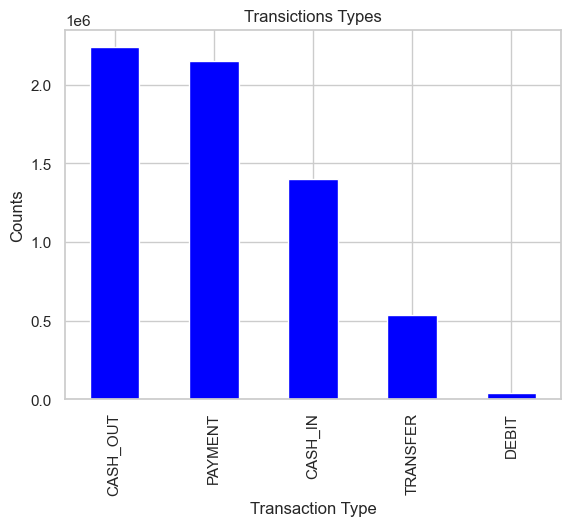

In [11]:
df["type"].value_counts().plot(kind="bar", title="Transictions Types", color="blue")
plt.xlabel("Transaction Type")
plt.ylabel("Counts")
plt.show()


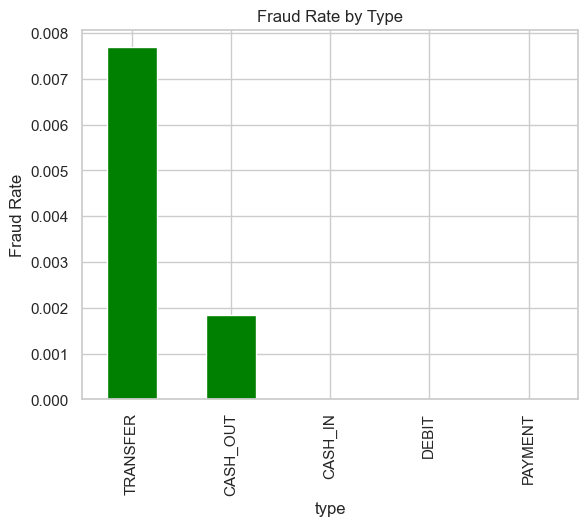

In [ ]:
# Now we are looking for fraud rates by type
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color="green")
plt.ylabel("Fraud Rate")
plt.show()

### Transaction Amount Analysis
Examine the statistical distribution of transaction amounts to identify patterns and outliers.

In [13]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

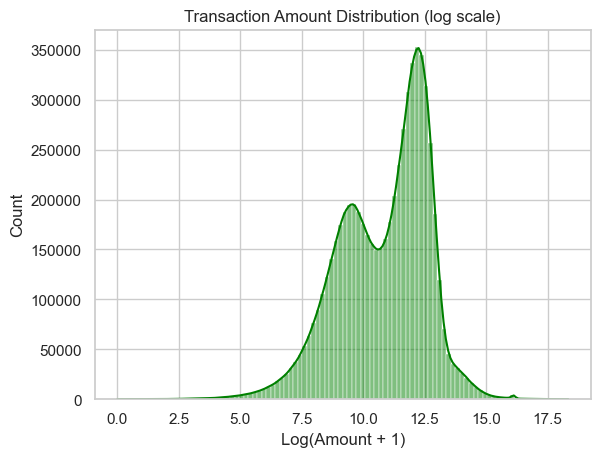

In [ ]:
# Getting the histogram

sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color="green")
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("Log(Amount + 1)")
plt.show()

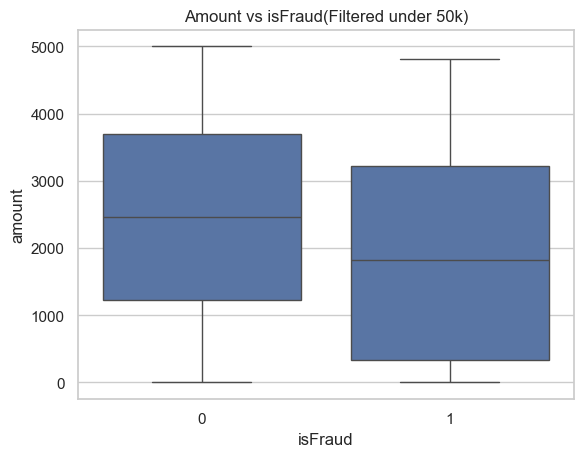

In [15]:
# now we are looking for the relationship between "isFraud" and "amount" 

sns.boxplot(data = df[df["amount"] < 5000], x="isFraud", y="amount")
plt.title("Amount vs isFraud(Filtered under 50k)")
plt.show()

## 3. Feature EngineeringCreate new features that may help the model detect fraud:
- **balanceDiffOrg**: Difference between old and new balance of the sender
- **balanceDiffDest**: Difference between old and new balance of the receiver

These features capture suspicious balance changes that could indicate fraudulent activity.

In [16]:
df["balanceDiffOrg"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [17]:
(df["balanceDiffOrg"] < 0).sum()

np.int64(1399253)

In [18]:
(df["balanceDiffDest"] < 0).sum()

np.int64(1238864)

## 4. Exploratory Data Analysis (EDA)Let's explore the dataset to understand its structure, column types, and basic statistics.
We start by previewing the first few rows of the data.

In [19]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrg,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


### Frauds Over Time
Plot the number of fraudulent transactions at each time step to identify temporal patterns in fraud occurrence.

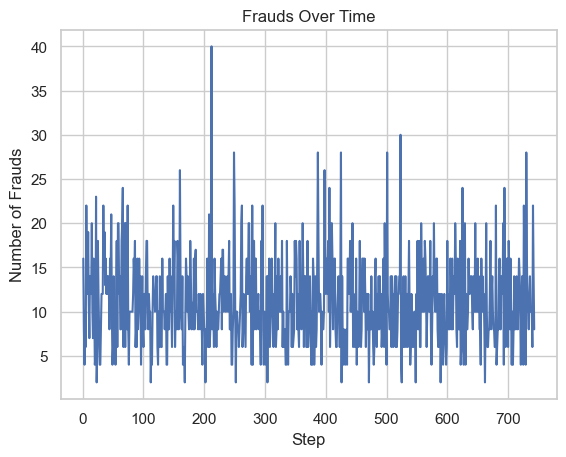

In [20]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label="Frauds per Step")
plt.xlabel("Step")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

### Drop Unnecessary Columns
Remove the `step` column as it has been analyzed and is no longer needed for modeling.

In [21]:
df.drop(columns='step', inplace=True)

In [22]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrg,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


## 5. Customer Behavior Analysis### Top Senders and Receivers
Identify the customers who make the highest number of transactions (top senders and top receivers).
This helps understand normal transaction patterns.

In [24]:
# we are going to find the customers that made the highest amount of transactions like top senders and top recievers

top_senders = df["nameOrig"].value_counts().head(10)

In [25]:
top_senders

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [26]:
tope_recievers = df["nameDest"].value_counts().head(10)

In [27]:
tope_recievers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

### Identify Fraudulent Customers
Find which customers have committed fraud and how many fraudulent transactions each has made.

In [29]:
#now we find the fraud making customers

fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)

In [30]:
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

## 6. Fraud Type AnalysisFilter the dataset to only include TRANSFER and CASH_OUT transactions,
since these are the only transaction types where fraud occurs in this dataset.

In [34]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]

In [35]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

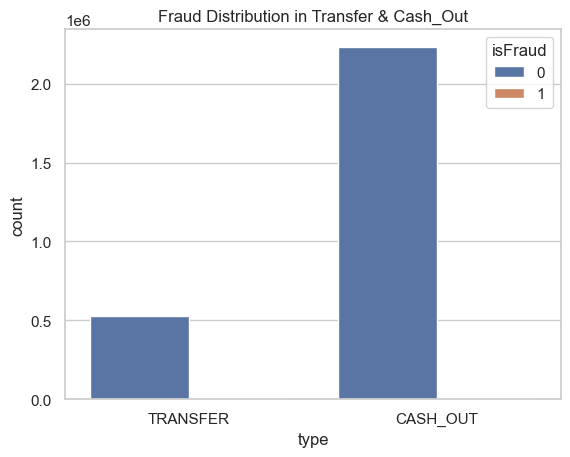

In [36]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud Distribution in Transfer & Cash_Out")
plt.show()

## 7. Correlation AnalysisCompute and visualize the correlation matrix between numerical features and the target variable.
This helps identify which features have the strongest relationship with fraud.

In [39]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()


In [40]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


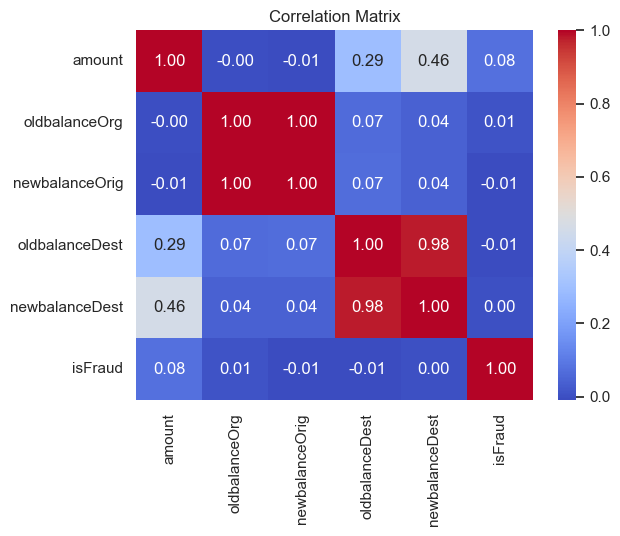

In [42]:
sns.heatmap(
    corr, 
    annot=True, 
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()


## 8. Suspicious Transaction DetectionIdentify transactions where the sender's balance drops to zero after a TRANSFER or CASH_OUT.
This is a strong indicator of potentially fraudulent activity.

In [43]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"])) 
]

In [44]:
len(zero_after_transfer)

1188074

In [ ]:
# this is the list of suspicious records
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrg,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


## 9. Machine Learning Model Preparation### Import ML Libraries
Import the necessary scikit-learn modules for:
- Splitting data into training and testing sets
- Scaling numerical features
- Building a Logistic Regression classifier
- Evaluating model performance
- Creating preprocessing pipelines

In [ ]:
from sklearn.model_selection import train_test_split #for splitting the data into training and testing sets
from sklearn.preprocessing import StandardScaler #for scaling
from sklearn.linear_model import LogisticRegression #for modeling
from sklearn.metrics import classification_report, confusion_matrix #for evaluating the model
from sklearn.pipeline import Pipeline #for training the model and doing the transforamtion operation
from sklearn.compose import ColumnTransformer #for data transformation 
from sklearn.preprocessing import OneHotEncoder #for data transformation 

### Prepare the Modeling Dataset
Drop columns that are not useful for the model:
- `nameOrig` and `nameDest`: Customer IDs (too many unique values to encode)
- `isFlaggedFraud`: This is a label, not a feature

In [47]:
# we are going to drop the columns that we are not using for modeling

df_model = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis=1)

In [49]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrg,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [58]:
categorial = ["type"]
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

### Define Features (X) and Target (y)
Separate the dataset into:
- **X**: All feature columns (input variables)
- **y**: The target column `isFraud` (what we want to predict)

In [ ]:
y = df_model["isFraud"]  # Target variable  
X = df_model.drop("isFraud", axis=1)  # Feature matrix (all columns except isFraud)  


In [ ]:
# Splitting the data where X_train and y_train holds 70% of data and X_test and y_test the rest of 30%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y

)

In [ ]:
#We are starting the preprocessing

preprocessor = ColumnTransformer(
    transformers= [
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorial)
    ],
    remainder= "drop"
)

In [64]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [67]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [69]:
y_pred = pipeline.predict(X_test)

In [71]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [72]:
confusion_matrix(y_test, y_pred)

array([[1802278,  104044],
       [    154,    2310]])

In [73]:
pipeline.score(X_test, y_test)

0.9454113766551095